# EDA — Feature Distributions & Class Separation

Use this notebook to visually tune distribution parameters in
`ml/synthetic/distributions.py` until fraud/normal classes overlap
realistically.

**Target:** 5–15% of fraud transactions below the 95th percentile of
normal transactions (for `amount`). If the value is far outside this
range, adjust `generate_normal_amount` / `generate_fraud_amount`
means and sigmas, then re-run the notebook.

In [1]:
import os, sys, json
from pathlib import Path

os.chdir(Path(os.getcwd()).resolve())
if os.path.basename(os.getcwd()) in ("notebooks", "ml"):
    os.chdir("..")
if "ml" not in os.listdir("."):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.synthetic import config
from ml.synthetic.build_dataset import build_dataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
accounts_df, transactions_df = build_dataset()
print(f"Accounts: {len(accounts_df)}, Transactions: {len(transactions_df)}")
print(f"Fraud ratio: {transactions_df['is_fraud'].mean():.2%}")

Accounts: 2000, Transactions: 20000
Fraud ratio: 3.00%


In [3]:
def overlap_metrics(feature: str, df: pd.DataFrame) -> dict:
    normal = df.loc[~df["is_fraud"], feature]
    fraud = df.loc[df["is_fraud"], feature]
    p95 = normal.quantile(0.95)
    fraud_below_p95 = (fraud < p95).mean() * 100
    return {
        "feature": feature,
        "normal_mean": normal.mean(),
        "fraud_mean": fraud.mean(),
        "normal_median": normal.median(),
        "fraud_median": fraud.median(),
        "normal_p95": p95,
        "fraud_below_normal_p95(%)": round(fraud_below_p95, 2),
    }

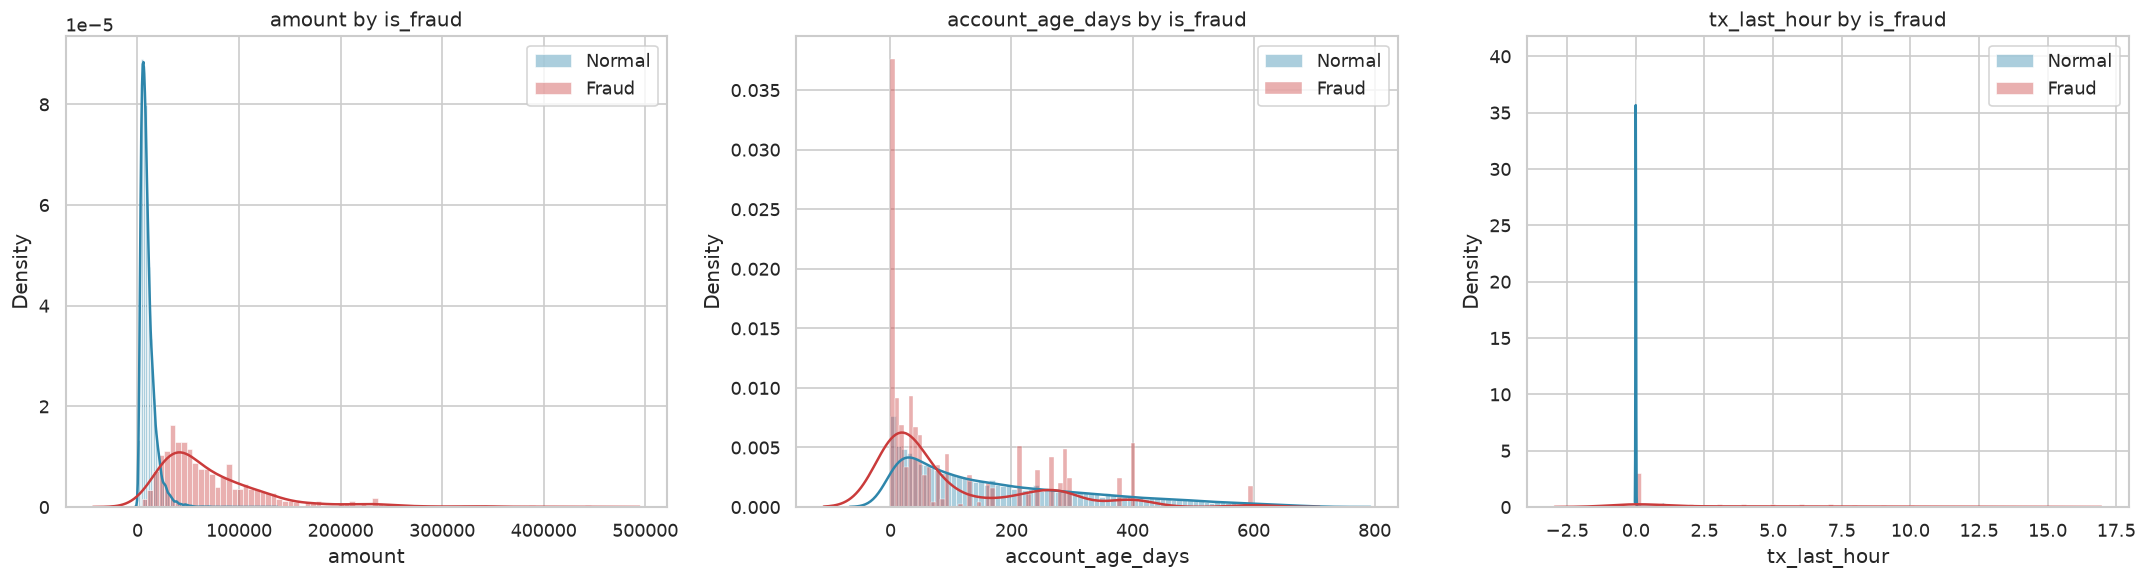

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ["amount", "account_age_days", "tx_last_hour"]
colors = {False: "#2e86ab", True: "#ca3b3b"}
labels = {False: "Normal", True: "Fraud"}

for ax, feat in zip(axes, features):
    for is_fraud in [False, True]:
        subset = transactions_df[transactions_df["is_fraud"] == is_fraud][feat]
        sns.histplot(
            subset, bins=80, color=colors[is_fraud], label=labels[is_fraud],
            stat="density", alpha=0.4, edgecolor=None, ax=ax,
        )
        sns.kdeplot(subset, color=colors[is_fraud], linewidth=1.5, ax=ax)
    ax.set_title(f"{feat} by is_fraud")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

In [5]:
metrics = pd.DataFrame(
    [overlap_metrics(feat, transactions_df) for feat in features]
)
metrics

,feature,normal_mean,fraud_mean,normal_median,fraud_median,normal_p95,fraud_below_normal_p95(%)
0,amount,10068.110613,73621.506583,8127.145,55741.305,23898.776,10.00
1,account_age_days,183.222216,101.103333,136.000,38.000,512.000,98.67
2,tx_last_hour,0.005979,2.536667,0.000,0.000,0.000,0.00


In [6]:
amount_ov = metrics.loc[
    metrics["feature"] == "amount", "fraud_below_normal_p95(%)"
].iloc[0]

if amount_ov < 5:
    msg = "WARNING: only {:.1f}% of fraud txs are below the 95th percentile of normal amount. Classes barely overlap — the model could cheat by thresholding amount alone. Move means/sigmas of generate_normal_amount and generate_fraud_amount closer in distributions.py, then Restart & Run All."
elif amount_ov > 15:
    msg = "INFO: {:.1f}% overlap — good, but watch for excessive noise."
else:
    msg = "OK: {:.1f}% overlap — realistic class separation."
print(msg.format(amount_ov))

OK: 10.0% overlap — realistic class separation.


## How to tune

1. Open `ml/synthetic/distributions.py`.
2. Adjust `generate_normal_amount` / `generate_fraud_amount`
   (they use `rng.lognormal(mean, sigma)`).
   Higher sigma = wider spread = more overlap.
3. **Restart & Run All** — dataset rebuilds deterministically (SEED=42).
4. Repeat until overlap is 5–15%.
5. Export final dataset: `python ml/synthetic/export_dataset.py`